In [15]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [16]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True
)

num_states = env.observation_space.n
num_actions = env.action_space.n

print("Number of states:", num_states)
print("Number of actions:", num_actions)



Number of states: 16
Number of actions: 4


In [17]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 50000

learning_rate = 0.1

gamma = 0.99

epsilon = 1.0

epsilon_min = 0.01

epsilon_decay = 0.9995

In [18]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((num_states, num_actions))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def choose_action(state, epsilon):

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    else:
        return np.argmax(Q[state])

In [19]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):

    # Reset environment
    state, info = env.reset()

    total_reward = 0

    for step in range(100):

        # Select action using epsilon-greedy
        action = choose_action(state, epsilon)

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Calculate target
        if terminated:
            target = reward
        else:
            target = reward + gamma * np.max(Q[next_state])

        # Update Q-value
        Q[state, action] = Q[state, action] + learning_rate * (
            target - Q[state, action]
        )

        # Move to next state
        state = next_state

        # Accumulate reward
        total_reward += reward

        # Stop episode if finished
        if terminated or truncated:
            break

    # Store total reward
    episode_rewards.append(total_reward)

    # Decay epsilon
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

In [20]:
# -------------------------------------------------
# Extract State-Value Function and Policy
# -------------------------------------------------

# State-value function
state_values = np.max(Q, axis=1)

# Learned policy
learned_policy = np.argmax(Q, axis=1)

In [21]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [22]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.555 0.514 0.504 0.514]
 [0.35  0.33  0.309 0.509]
 [0.412 0.433 0.428 0.477]
 [0.271 0.338 0.299 0.455]
 [0.575 0.209 0.395 0.478]
 [0.    0.    0.    0.   ]
 [0.188 0.153 0.261 0.13 ]
 [0.    0.    0.    0.   ]
 [0.455 0.479 0.333 0.612]
 [0.495 0.661 0.477 0.302]
 [0.643 0.391 0.469 0.31 ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.527 0.373 0.77  0.475]
 [0.743 0.894 0.788 0.733]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.555 0.509 0.477 0.455]
 [0.575 0.    0.261 0.   ]
 [0.612 0.661 0.643 0.   ]
 [0.    0.77  0.894 0.   ]]

Learned Policy:
[['L' 'U' 'U' 'U']
 ['L' 'L' 'R' 'L']
 ['U' 'D' 'L' 'L']
 ['L' 'R' 'D' 'L']]

Average reward over last 1000 episodes: 0.681


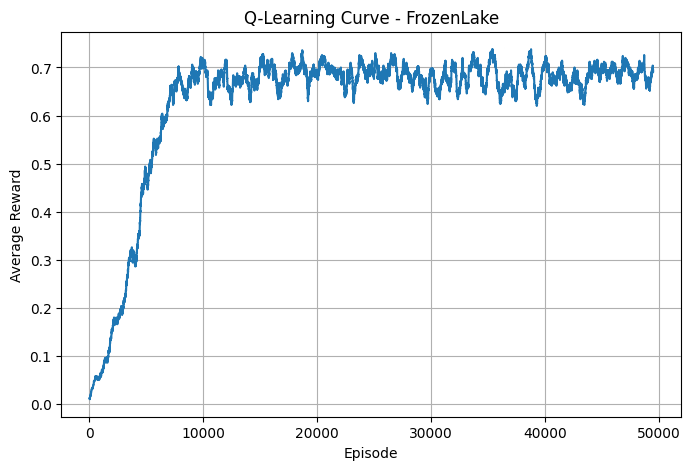

In [23]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()